# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from scipy.stats import zscore
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, \
    roc_curve, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')
base.head()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0


In [3]:
# seu código aqui
base.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             10000 non-null  int64
 1   gender          10000 non-null  int64
 2   height          10000 non-null  int64
 3   weight          10000 non-null  str  
 4   cholesterol     10000 non-null  int64
 5   gluc            10000 non-null  int64
 6   smoke           10000 non-null  int64
 7   alco            10000 non-null  int64
 8   active          10000 non-null  int64
 9   cardio_disease  10000 non-null  int64
dtypes: int64(9), str(1)
memory usage: 781.4 KB


In [4]:
base["weight"].unique()

<StringArray>
[  '62',   '85',   '64',   '82',   '56',   '67',   '93',   '95',   '71',
   '68',
 ...
  '136', '82,9',  '154', '68,9',  '170', '84,5',  '135', '72,5',  '146',
 '70,5']
Length: 140, dtype: str

In [5]:
base["weight"] = base["weight"].str.replace({",": "."}).astype(float)
base.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,74.303710,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,14.566353,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
z_height = zscore(base["height"], ddof=1)
z_height

array([ 0.45138674, -1.0158219 ,  0.08458458, ..., -0.77128713,
        0.45138674, -0.1599502 ], shape=(10000,))

In [7]:
# Remover outlier de altura e peso

base = base[(z_height > -3) & (z_height < 3)]
z_weight = zscore(base["weight"], ddof=1)
base = base[(z_weight > -3) & (z_weight < 3)]
base.shape

(9855, 10)

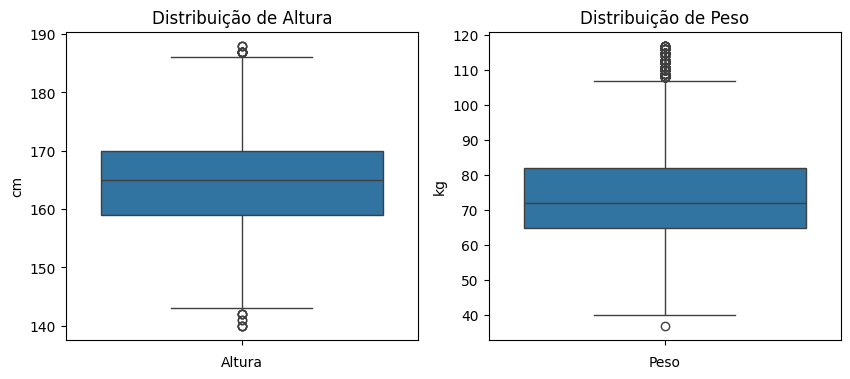

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(base, y="height", ax=axes[0])
axes[0].set_title("Distribuição de Altura")
axes[0].set_xlabel("Altura")
axes[0].set_ylabel("cm")

sns.boxplot(base, y="weight", ax=axes[1])
axes[1].set_title("Distribuição de Peso")
axes[1].set_xlabel("Peso")
axes[1].set_ylabel("kg")

plt.show()

# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


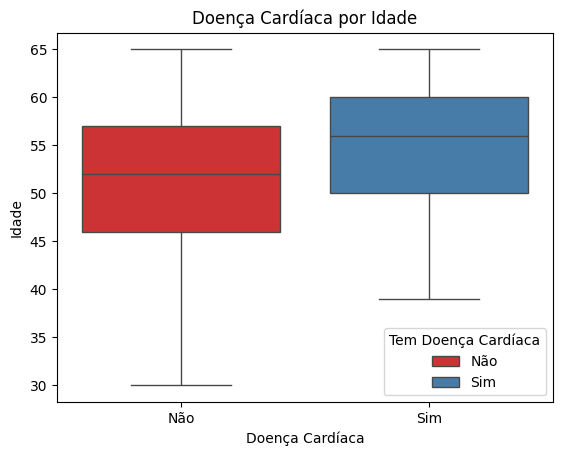

In [9]:
# Idade X Doença Cardíaca
sns.boxplot(base, x="cardio_disease", y="age", hue="cardio_disease", palette="Set1")
plt.title("Doença Cardíaca por Idade")
plt.xlabel("Doença Cardíaca")
plt.ylabel("Idade")
plt.xticks([0, 1], labels=["Não", "Sim"])
plt.legend(["Não", "Sim"], title="Tem Doença Cardíaca")
plt.show()

As pessoas com doença cardíaca tendem a ser mais velhas do que as pessoas sem doença cardíaca. Porém isso não é um indicador incontestável, pois com doenças cardíacas estão na faixa acima de 50 anos, entretanto existem muitos 50+ sem problemas cardíacos.

In [10]:
colesterol_ = (
    base.groupby(["cardio_disease", "cholesterol"], as_index=False)
    [["cardio_disease", "cholesterol"]]
    .size()
    .rename(columns={"size": "total"})
)
colesterol_["per"] = (colesterol_["total"] / base.shape[0]) * 100
colesterol_

,cardio_disease,cholesterol,total,per
0,0,1,4107,41.674277
1,0,2,567,5.753425
2,0,3,243,2.465753
3,1,1,3280,33.282598
4,1,2,786,7.975647
5,1,3,872,8.848300


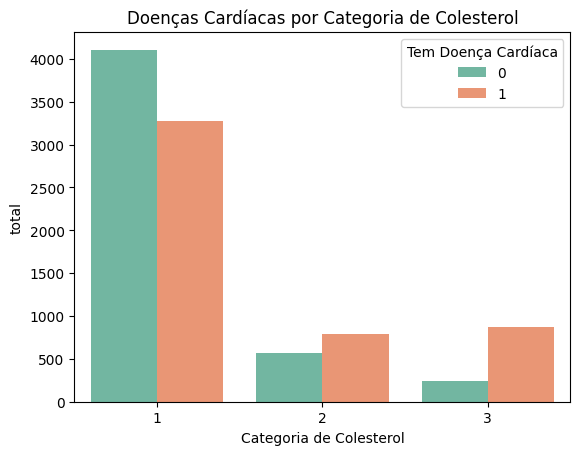

In [11]:
# Colesterol X Doença Cardíaca
sns.barplot(colesterol_, x="cholesterol", y="total", hue="cardio_disease", palette="Set2")
plt.title("Doenças Cardíacas por Categoria de Colesterol")
plt.xlabel("Categoria de Colesterol")
plt.legend(title="Tem Doença Cardíaca")
plt.show()

À medida que a categoria de colesterol aumenta, aumenta também a proporção de pessoas com doença cardíaca. Na categoria 1, os casos com doença são minoria; na categoria 2, passam a ser maioria; e na categoria 3, representam uma parcela ainda maior.

In [12]:
atividade_doenca = (
    base.groupby(["cardio_disease", "active"], as_index=False)
    [["cardio_disease", "active"]]
    .size()
    .rename(columns={"size": "total"})
)
atividade_doenca

,cardio_disease,active,total
0,0,0,919
1,0,1,3998
2,1,0,1078
3,1,1,3860


In [13]:
base["cardio_disease"].value_counts()

cardio_disease
1    4938
0    4917
Name: count, dtype: int64

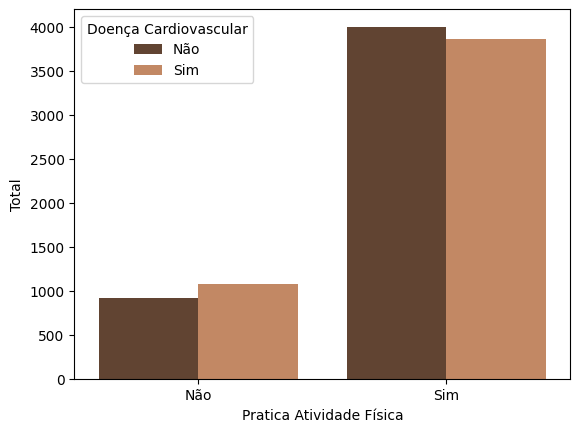

In [14]:
# Faz Atividade Física X Doença Cardíaca
sns.barplot(atividade_doenca, x="active", y="total", hue="cardio_disease", palette="copper")
plt.xticks(ticks=[0, 1], labels=["Não", "Sim"])
plt.xlabel("Pratica Atividade Física")
plt.ylabel("Total")
plt.legend(
    title="Doença Cardiovascular",
    labels=["Não", "Sim"], 
    handles=plt.gca().get_legend_handles_labels()[0]
)
plt.show()

A maioria dos pacientes pratica alguma atividade física e a proporção de pacientes doentes e saudáveis é quase igual nos dois cenários. A atividade física por si só não impede a ocorrência da pessoa sofrer com problemas do coração.

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



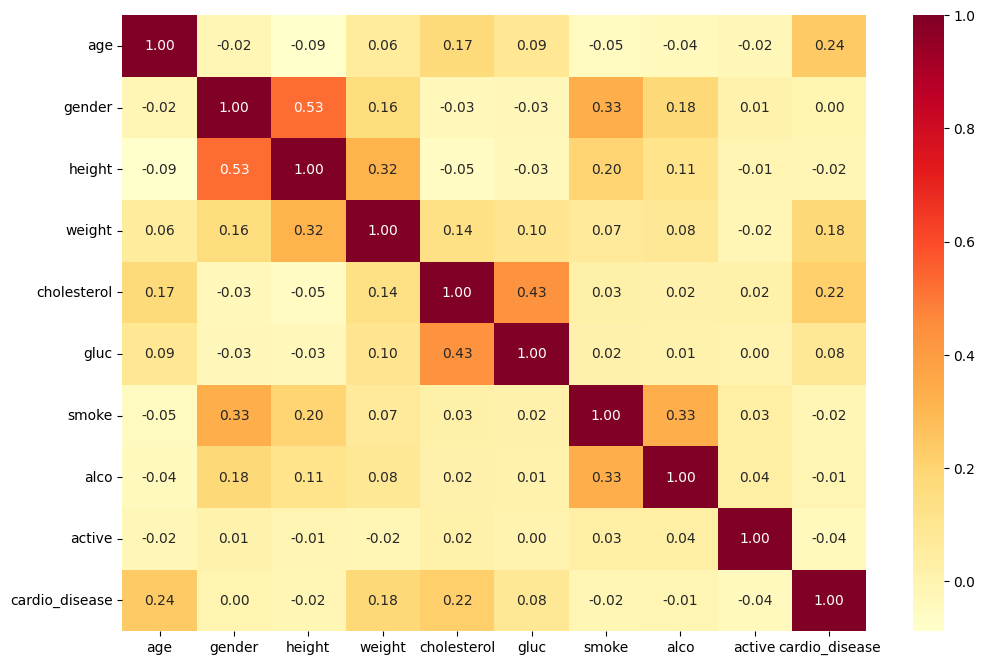

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(base.corr(), annot=True, cmap="YlOrRd", fmt=".2f")
plt.show()

As colunas que têm maior correlação com cardio_disease são idade (0.24), colesterol (0.22) e peso (0.18) porém nenhuma delas têm correlação forte com a cardio_disease o que indica que elas isoladamente não implicam em doenças cardíacas. Altura e peso tem um relação mediana, pessoas altas tendem a serem mais pesadas e gênero com altura se relacionam mais fortemente, aqui mulheres são mais altas. Além disso, gênero tem relação interessante com fumar, indicando que o hábito de fumar é mais comum em mulheres. E para finalizar colesterol e glicose têm uma boa relação, pacientes que têm um possivelmente terão o outro também.

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [16]:
X = base.drop("cardio_disease", axis=1)
y = base["cardio_disease"]

In [17]:
display("X", X)
display("y", y)

'X'

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active
0,50,2,168,62.0,1,1,0,0,1
1,55,1,156,85.0,3,1,0,0,1
2,52,1,165,64.0,3,1,0,0,0
3,48,2,169,82.0,1,1,0,0,1
4,48,1,156,56.0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...
9995,56,1,166,65.0,1,1,0,0,0
9996,50,1,160,93.0,2,1,0,0,1
9997,40,1,158,66.0,2,2,0,0,1
9998,50,1,168,70.0,3,1,0,0,1


'y'

0       0
1       1
2       1
3       1
4       0
       ..
9995    0
9996    1
9997    0
9998    1
9999    1
Name: cardio_disease, Length: 9855, dtype: int64

In [18]:
scaler = StandardScaler()

X = scaler.fit_transform(X)
# pd.DataFrame(X, columns=X_train.columns)

In [19]:
# seu código aqui
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [20]:
y_train.value_counts()

cardio_disease
0    3715
1    3676
Name: count, dtype: int64

As classes da variável alvo estão bem próximas em quantidade então não vou gerar dados sintéticos.

In [21]:
display("X_train", X_train)
display("X_test", X_test)
display("y_train", y_train)
display("y_test", y_test)

'X_train'

array([[ 0.69093098,  1.3822134 ,  0.74422521, ..., -0.31117205,
        -0.23769007, -1.98365883],
       [-0.04484063,  1.3822134 ,  0.74422521, ..., -0.31117205,
        -0.23769007,  0.50411895],
       [ 0.54377665,  1.3822134 ,  0.61398745, ...,  3.21365621,
        -0.23769007,  0.50411895],
       ...,
       [ 0.39662233, -0.72347729, -0.8186279 , ..., -0.31117205,
        -0.23769007, -1.98365883],
       [ 1.13239394, -0.72347729, -1.99076773, ..., -0.31117205,
        -0.23769007,  0.50411895],
       [-0.19199495,  1.3822134 ,  1.00470072, ..., -0.31117205,
        -0.23769007,  0.50411895]], shape=(7391, 9))

'X_test'

array([[ 0.39662233, -0.72347729, -0.55815239, ..., -0.31117205,
        -0.23769007,  0.50411895],
       [-1.51638385, -0.72347729, -0.55815239, ..., -0.31117205,
        -0.23769007,  0.50411895],
       [ 0.24946801,  1.3822134 , -0.55815239, ...,  3.21365621,
        -0.23769007,  0.50411895],
       ...,
       [ 0.69093098, -0.72347729, -0.68839014, ..., -0.31117205,
        -0.23769007,  0.50411895],
       [ 1.72101123,  1.3822134 ,  0.09303641, ..., -0.31117205,
        -0.23769007,  0.50411895],
       [-0.78061224, -0.72347729,  0.48374969, ..., -0.31117205,
        -0.23769007, -1.98365883]], shape=(2464, 9))

'y_train'

8892    1
7996    0
4734    1
9051    1
7176    1
       ..
9361    0
4930    1
3310    0
9990    1
2769    0
Name: cardio_disease, Length: 7391, dtype: int64

'y_test'

8208    0
9907    1
9222    0
9207    1
4878    1
       ..
1922    1
9634    1
9043    0
968     0
1249    0
Name: cardio_disease, Length: 2464, dtype: int64

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [22]:
# seu código aqui
modelo = LogisticRegression()

modelo.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [23]:
print(f"Intercept={modelo.intercept_}\nCoeficiente={modelo.coef_}")

Intercept=[0.00112548]
Coeficiente=[[ 0.42489899  0.02326341 -0.12342198  0.3608632   0.41479515 -0.07640442
  -0.02091444 -0.04514466 -0.07621364]]


In [24]:
y_pred = modelo.predict(X_train)

In [25]:
result = classification_report(y_train, y_pred)
print(result)

              precision    recall  f1-score   support

           0       0.63      0.67      0.65      3715
           1       0.65      0.60      0.62      3676

    accuracy                           0.64      7391
   macro avg       0.64      0.64      0.64      7391
weighted avg       0.64      0.64      0.64      7391



O modelo atingiu uma acurácia razoável, 64% não é um resultado tão bom e quando analisado o recall da classe 1, 60% fica menos animador. Por se tratar de um modelo que prevê doenças cardíacas seria mais interessante ter um recall maior para evitar que o modelo classifique pacientes como Falsos Negativos.

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [26]:
y_pred = modelo.predict(X_test)

In [27]:
result = classification_report(y_test, y_pred)
print(result)

              precision    recall  f1-score   support

           0       0.61      0.67      0.64      1202
           1       0.65      0.59      0.62      1262

    accuracy                           0.63      2464
   macro avg       0.63      0.63      0.63      2464
weighted avg       0.63      0.63      0.63      2464



In [28]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
print("Curva ROC", roc_auc)

Curva ROC 0.630837141478413


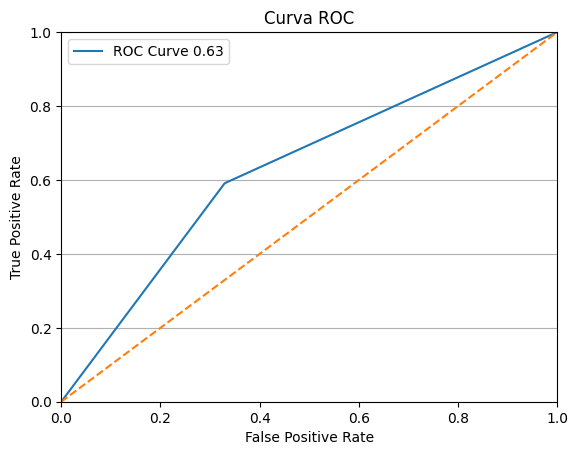

In [29]:
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve %.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(axis="y")
plt.title("Curva ROC")
plt.legend(loc="upper left")
plt.show()

O modelo atual é capaz de identificar corretamente 63% dos pacientes com doenças cardíacas pouco acima de 50%. Não é o ideal para o cenário atual, pois muitos pacientes True Positives estão sendo deixados passar pelo modelo.

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



A) Regressão Logística é um modelo de classificação binária. Usa o cálculo de regressão para obter a probabilidade de um determinado evento ocorrer.

B) Porque transforma as probabilidades estimadas em categorias (verdadeiro ou falso) com base no limiar das classes. Com o cálcula sigmoide as probabilidades são transformadas em uma das duas classes.

C) A Regressão Logística usa a regressão linear das variáveis independentes e estimam coeficientes para cada variável, até aqui ambos modelos são iguais. A diferença é que a Regressão Logística faz um passo extra: aplica a função sigmoide para transformar os resultados em uma probabilidade entre 0 e 1.